
COMPLETE MACHINE LEARNING PIPELINE WITH NEURAL NETWORKS
PROPER DATA LEAKAGE PREVENTION IMPLEMENTED

Initializing TensorFlow...
TensorFlow Version: 2.19.0
Num GPUs Available: 1

LOADING AND PREPARING DATA
Original dataset shape: (657, 125)

Initial data summary:
  Samples: 657
  Features: 124
  Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  Class distribution: {1: np.int64(240), 2: np.int64(255), 3: np.int64(102), 4: np.int64(60)}

PREPROCESSING PIPELINE - FITTING ON TRAINING DATA
   Original features: 124
   Found 1 constant columns
   Found 15 columns with >50.0% missing values
   Found 44 highly correlated columns
   Selected 30 features out of 64

   Training set shape after preprocessing: (525, 30)
   Preprocessor fitted successfully
Dropping 2 unwanted features: ['Age', 'BMI']
['HeartRate']
['Eng_Age_x_THD', 'Eng_Age_x_HeartRate', 'Eng_BMI_x_HarmonicRatio', 'Eng_CV_Stress_Index', 'Eng_Dipping_Autonomic_Function', 'Eng_HTN_Progression_Risk', 'Eng_HTN_Prehyper_Disc

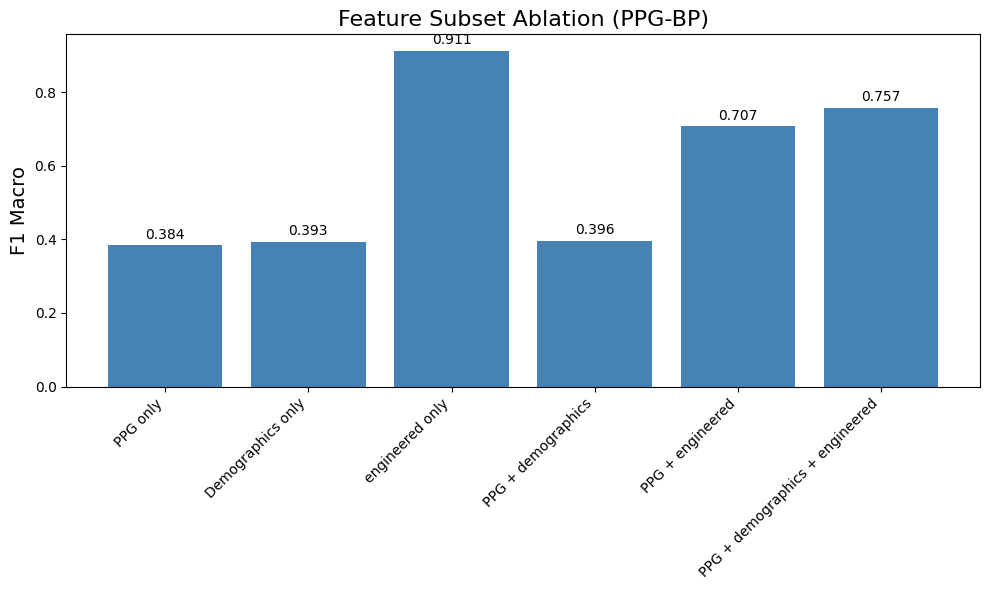


MODEL BUILDING AND EVALUATION

Data split:
  Training set: (525, 124)
  Testing set: (132, 124)
  Training class distribution: [  0 192 204  81  48]
  Testing class distribution: [ 0 48 51 21 12]

PREPROCESSING PIPELINE - FITTING ON TRAINING DATA
   Original features: 124
   Found 1 constant columns
   Found 15 columns with >50.0% missing values
   Found 44 highly correlated columns
   Selected 30 features out of 64

   Training set shape after preprocessing: (525, 30)
   Preprocessor fitted successfully

   Applying transformations to new data...
   Transformed data shape: (525, 30)

   Applying transformations to new data...
   Transformed data shape: (132, 30)

After preprocessing:
  Training set shape: (525, 30)
  Testing set shape: (132, 30)
  Selected features: 30
Dropping 2 unwanted features: ['Age', 'BMI']

CROSS-VALIDATION RESULTS (5-fold)

Random Forest:
  Fold 1 HT-2 F1: 0.714
  Fold 2 HT-2 F1: 0.143
  Fold 3 HT-2 F1: 0.533
  Fold 4 HT-2 F1: 0.444
  Fold 5 HT-2 F1: 0.571
  

<Figure size 1200x800 with 0 Axes>

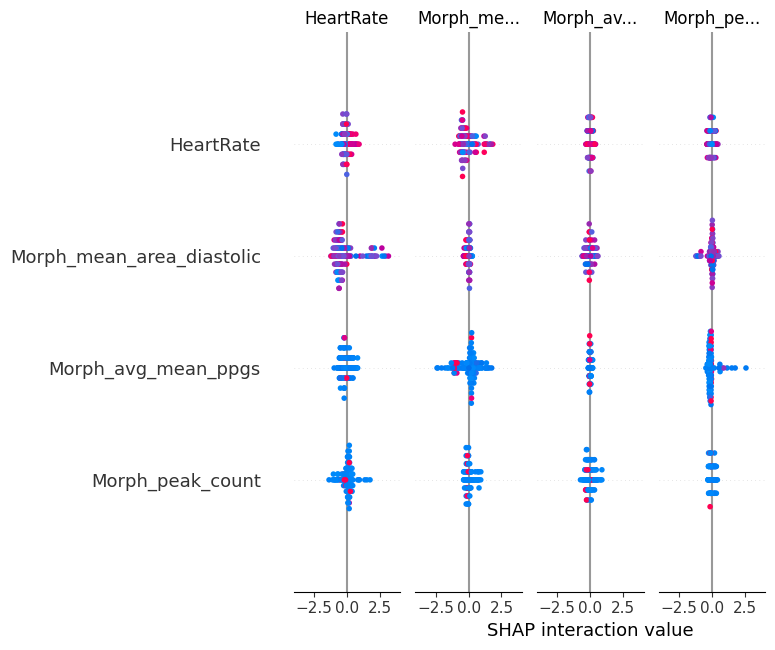

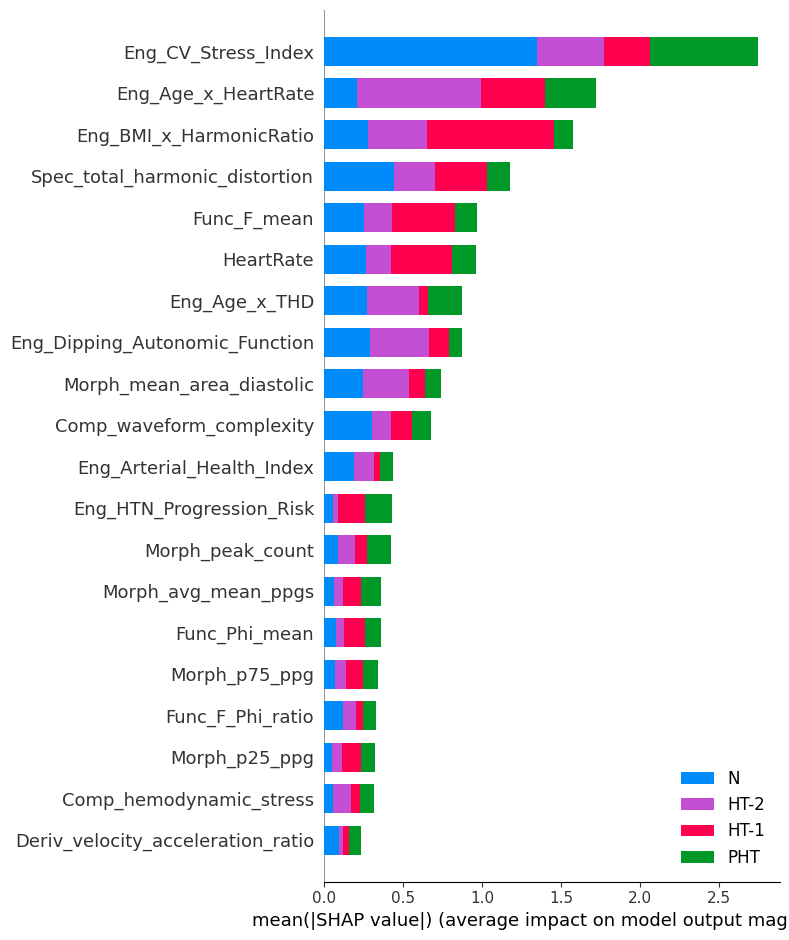


Top 5 features per class by mean |SHAP|:

N:
  HeartRate: 0.1999
  Morph_peak_count: 0.1534
  Morph_mean_area_diastolic: 0.1238
  Morph_avg_mean_ppgs: 0.1163

PHT:
  Morph_avg_mean_ppgs: 0.2467
  HeartRate: 0.2229
  Morph_peak_count: 0.1591
  Morph_mean_area_diastolic: 0.1481

HT-1:
  Morph_mean_area_diastolic: 0.2233
  HeartRate: 0.1896
  Morph_avg_mean_ppgs: 0.1465
  Morph_peak_count: 0.0929

HT-2:
  Morph_mean_area_diastolic: 0.1907
  Morph_avg_mean_ppgs: 0.1657
  HeartRate: 0.1621
  Morph_peak_count: 0.1142


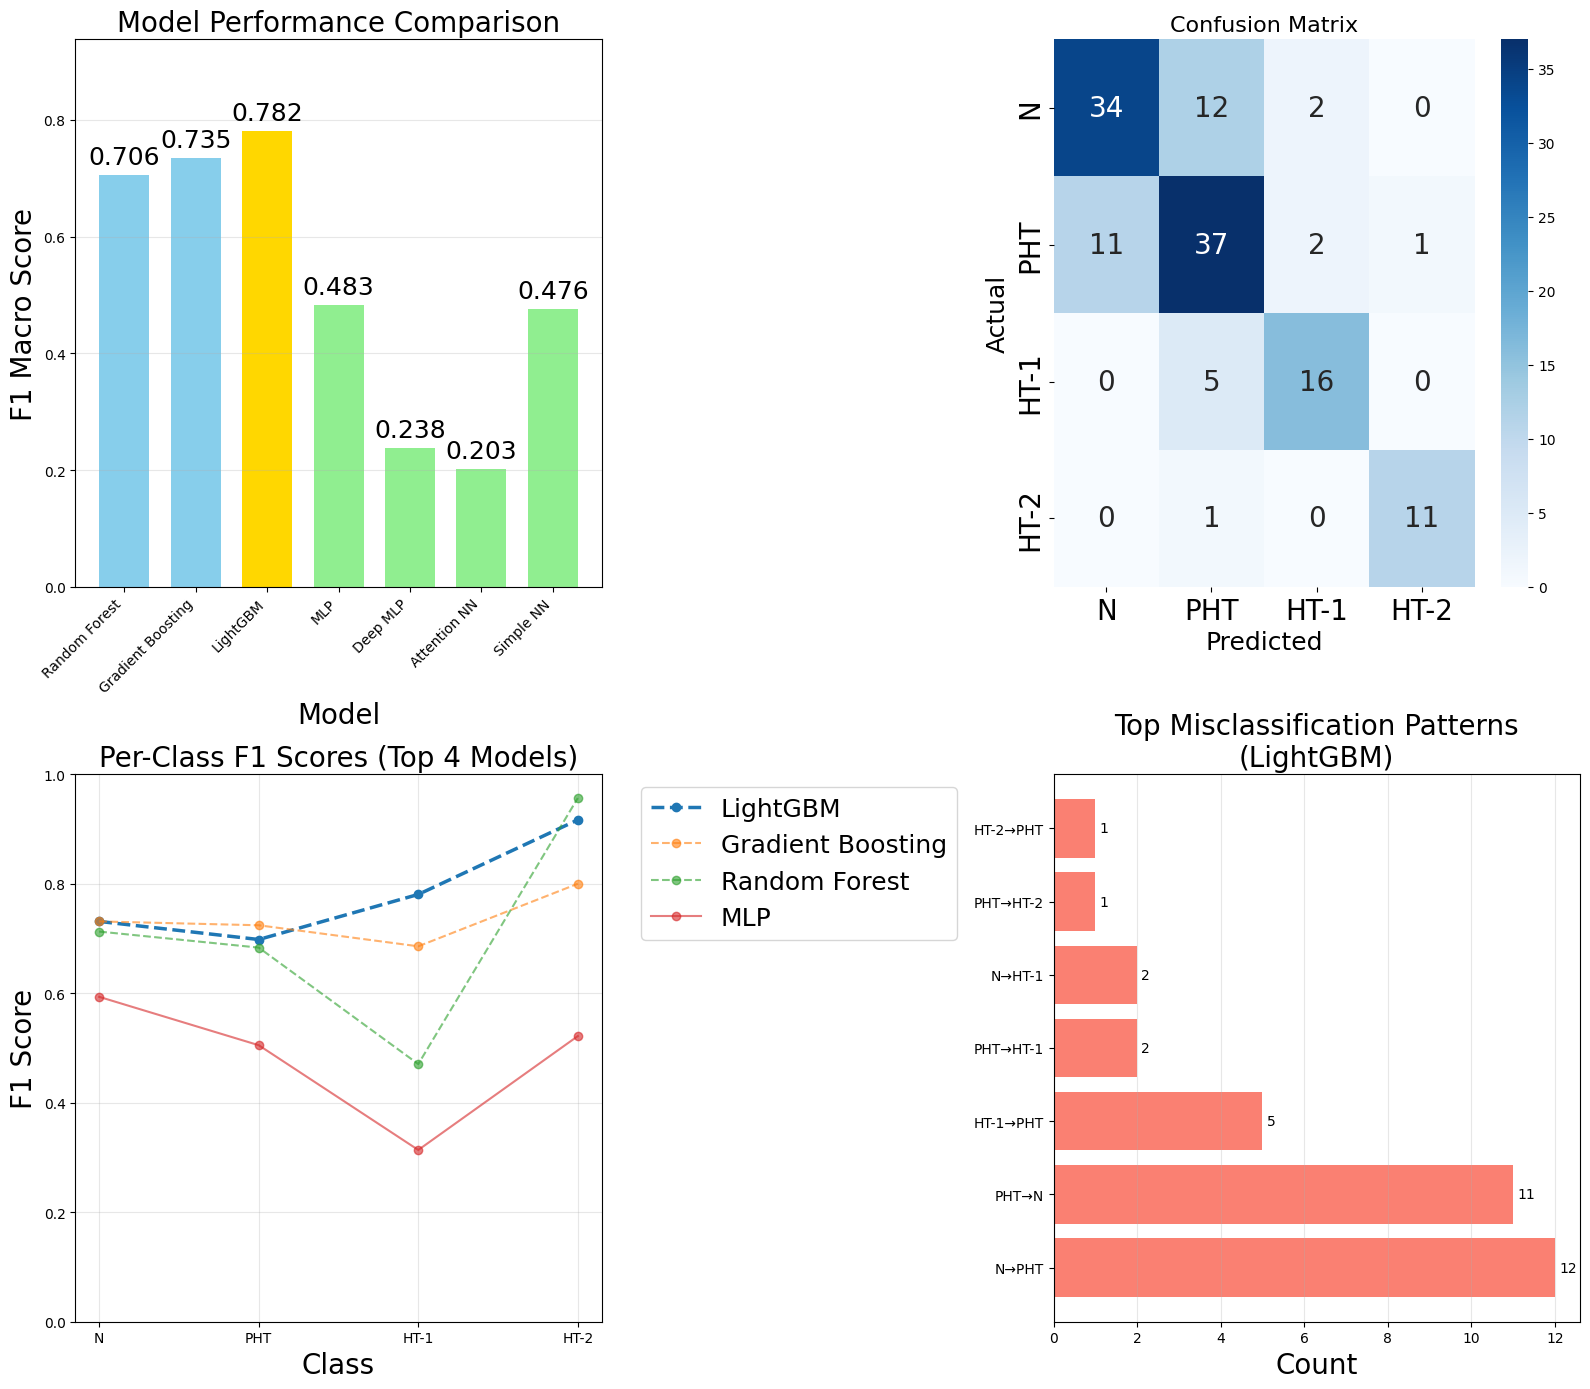

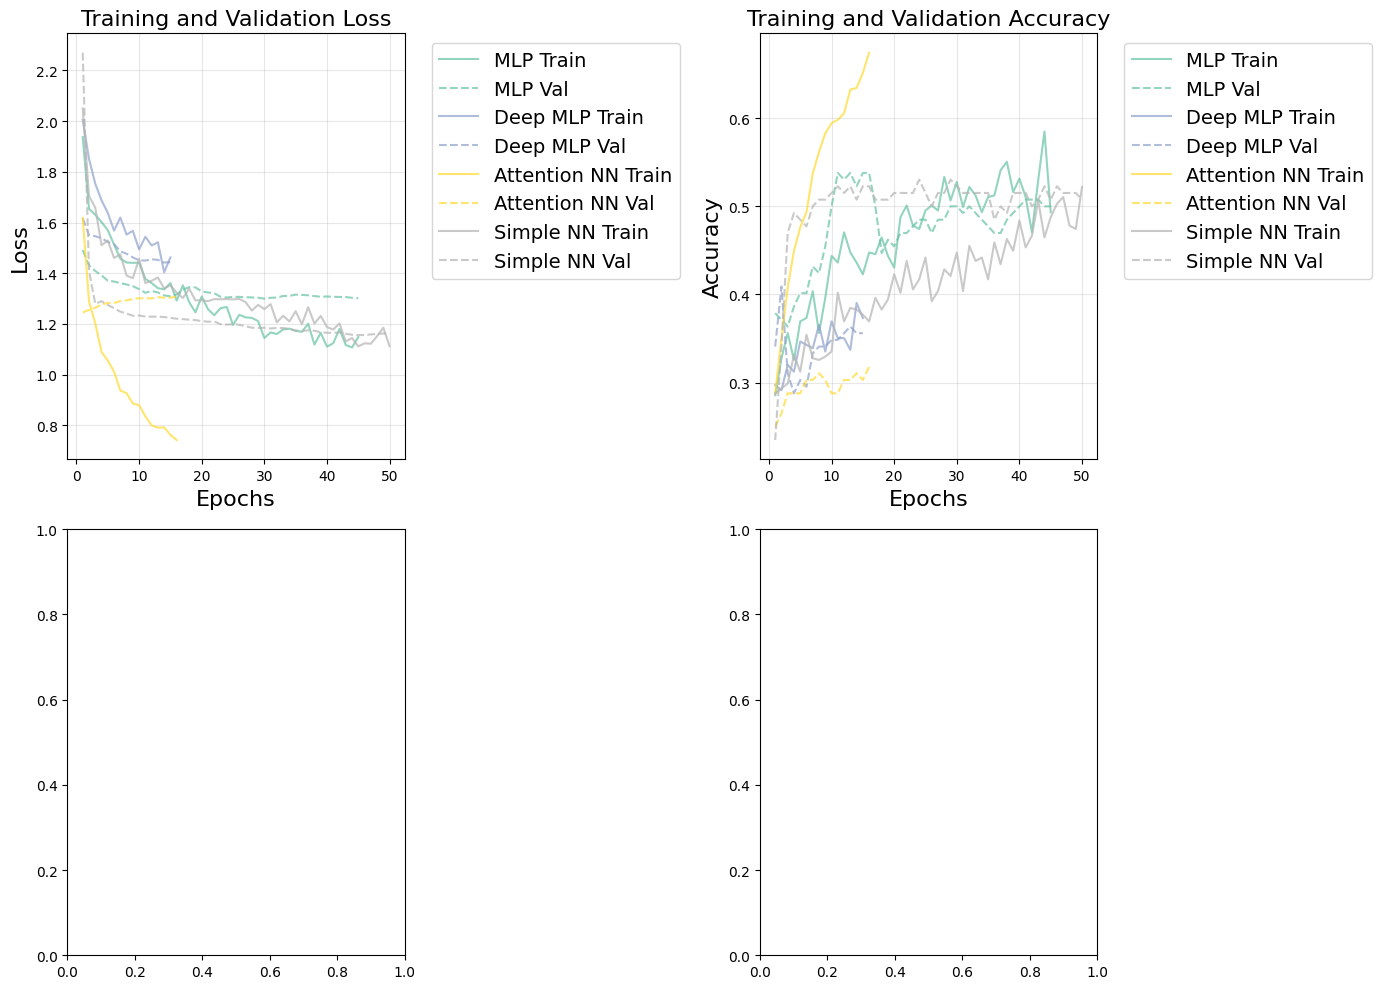

['HeartRate', 'Morph_peak_count', 'Morph_mean_area_diastolic', 'Morph_avg_mean_ppgs', 'Morph_p25_ppg', 'Morph_p75_ppg', 'Morph_mean_step_duration', 'Func_F_mean', 'Func_Phi_mean', 'Func_Psi_mean', 'Func_F_Phi_ratio', 'Temp_heart_rate_variability', 'Deriv_max_acceleration', 'Deriv_velocity_acceleration_ratio', 'Spec_harmonic_ratio', 'Spec_total_harmonic_distortion', 'Comp_waveform_complexity', 'Comp_hemodynamic_stress', 'Eng_Age_x_THD', 'Eng_Age_x_HeartRate', 'Eng_BMI_x_HarmonicRatio', 'Eng_CV_Stress_Index', 'Eng_Dipping_Autonomic_Function', 'Eng_HTN_Progression_Risk', 'Eng_HTN_Prehyper_Discriminator', 'Eng_Clinical_ISH_Proxy', 'Eng_Clinical_Young_HT_Pattern', 'Eng_Arterial_Health_Index']


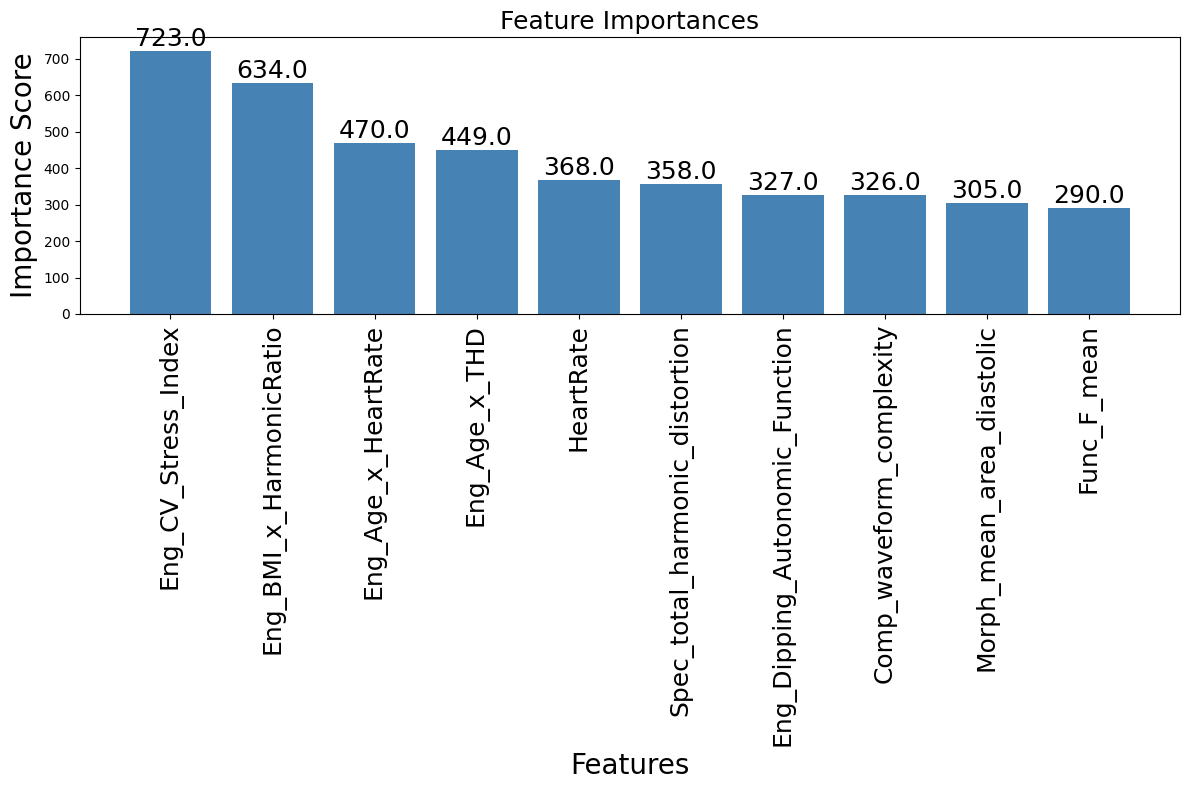


Top 10 most important features:
  1. Eng_CV_Stress_Index: 723.0
  2. Eng_BMI_x_HarmonicRatio: 634.0
  3. Eng_Age_x_HeartRate: 470.0
  4. Eng_Age_x_THD: 449.0
  5. HeartRate: 368.0
  6. Spec_total_harmonic_distortion: 358.0
  7. Eng_Dipping_Autonomic_Function: 327.0
  8. Comp_waveform_complexity: 326.0
  9. Morph_mean_area_diastolic: 305.0
  10. Func_F_mean: 290.0

ENSEMBLE MODEL
Creating ensemble from 3 models: ['Random Forest', 'Gradient Boosting', 'LightGBM']

Ensemble Performance:
  Accuracy: 0.712
  F1 Macro: 0.750
  F1 Weighted: 0.713

Ensemble Classification Report:
              precision    recall  f1-score   support

     Class 1       0.76      0.67      0.71        48
     Class 2       0.62      0.76      0.68        51
     Class 3       0.75      0.57      0.65        21
     Class 4       1.00      0.92      0.96        12

    accuracy                           0.71       132
   macro avg       0.78      0.73      0.75       132
weighted avg       0.73      0.71      0

In [ ]:
import numpy as np
import pandas as pd
import shap

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore')

# ==================== PREPROCESSING PIPELINE ====================

class DataPreprocessor(BaseEstimator, TransformerMixin):
    """Custom preprocessor that prevents data leakage"""

    def __init__(self, k_features=30, missing_threshold=0.5, corr_threshold=0.95):
        self.k_features = k_features
        self.missing_threshold = missing_threshold
        self.corr_threshold = corr_threshold

        # Components to be fitted during training
        self.constant_cols_ = None
        self.high_missing_cols_ = None
        self.correlated_cols_ = None
        self.imputer_ = None
        self.selector_ = None
        self.scaler_ = None
        self.selected_features_ = None
        self.all_features_ = None  # Store all features before selection
        self.feature_mask_ = None  # Boolean mask for selected features

    def fit(self, X, y=None):
        """Fit preprocessor on training data only"""
        X = X.copy()

        print("\n" + "="*80)
        print("PREPROCESSING PIPELINE - FITTING ON TRAINING DATA")
        print("="*80)

        # Store original feature names
        self.all_features_ = X.columns.tolist()
        print(f"   Original features: {len(self.all_features_)}")

        # 1. Identify constant columns
        self.constant_cols_ = [col for col in X.columns if X[col].nunique() == 1]
        if self.constant_cols_:
            print(f"   Found {len(self.constant_cols_)} constant columns")
            X = X.drop(columns=self.constant_cols_)

        # 2. Handle infinite values
        X = X.replace([np.inf, -np.inf], np.nan)

        # 3. Identify columns with >threshold missing values
        missing_percent = X.isnull().sum() / len(X)
        self.high_missing_cols_ = missing_percent[missing_percent > self.missing_threshold].index.tolist()
        if self.high_missing_cols_:
            print(f"   Found {len(self.high_missing_cols_)} columns with >{self.missing_threshold*100}% missing values")
            X = X.drop(columns=self.high_missing_cols_)

        # 4. Fit imputer on remaining columns
        self.imputer_ = SimpleImputer(strategy='median')
        X_imputed = self.imputer_.fit_transform(X)
        X = pd.DataFrame(X_imputed, columns=X.columns)

        # 5. Identify highly correlated features
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.correlated_cols_ = [column for column in upper.columns if any(upper[column] > self.corr_threshold)]
        if self.correlated_cols_:
            print(f"   Found {len(self.correlated_cols_)} highly correlated columns")
            X = X.drop(columns=self.correlated_cols_)

        # 6. Feature selection
        if y is not None:
            # Store features before selection
            features_before_selection = X.columns.tolist()

            # Create selector and fit it
            self.selector_ = SelectKBest(score_func=f_classif, k=min(self.k_features, X.shape[1]))
            self.selector_.fit(X, y)

            # Get feature mask and selected features
            self.feature_mask_ = self.selector_.get_support()
            self.selected_features_ = X.columns[self.feature_mask_].tolist()

            print(f"   Selected {len(self.selected_features_)} features out of {len(features_before_selection)}")
            if len(self.selected_features_) <= 20:
                print(f"   Selected features: {self.selected_features_}")
        else:
            self.selected_features_ = X.columns.tolist()
            self.feature_mask_ = np.ones(len(self.selected_features_), dtype=bool)
            print(f"   Using all {len(self.selected_features_)} features (no y provided)")

        # 7. Fit scaler on selected features only
        # First get the selected data
        X_selected = X[self.selected_features_] if self.selector_ is not None else X
        self.scaler_ = RobustScaler()
        self.scaler_.fit(X_selected)

        print(f"\n   Training set shape after preprocessing: {X_selected.shape}")
        print("   Preprocessor fitted successfully")

        return self

    def transform(self, X, y=None):
        """Apply transformations learned from training data"""
        X = X.copy()

        print("\n   Applying transformations to new data...")

        # 1. Remove constant columns (if they exist in the data)
        if self.constant_cols_:
            constant_to_remove = [col for col in self.constant_cols_ if col in X.columns]
            if constant_to_remove:
                X = X.drop(columns=constant_to_remove)

        # 2. Handle infinite values
        X = X.replace([np.inf, -np.inf], np.nan)

        # 3. Remove high missing columns (if they exist in the data)
        if self.high_missing_cols_:
            high_missing_to_remove = [col for col in self.high_missing_cols_ if col in X.columns]
            if high_missing_to_remove:
                X = X.drop(columns=high_missing_to_remove)

        # 4. Impute missing values with training medians
        if self.imputer_ is not None:
            # Ensure all columns expected by the imputer are present
            imputer_columns = self.imputer_.feature_names_in_ if hasattr(self.imputer_, 'feature_names_in_') else None

            if imputer_columns is not None:
                # Add missing columns with 0
                missing_cols = set(imputer_columns) - set(X.columns)
                for col in missing_cols:
                    X[col] = 0
                # Reorder columns to match imputer expectations
                X = X[imputer_columns]

            X_imputed = self.imputer_.transform(X)
            X = pd.DataFrame(X_imputed, columns=X.columns)

        # 5. Remove correlated columns (if they exist in the data)
        if self.correlated_cols_:
            correlated_to_remove = [col for col in self.correlated_cols_ if col in X.columns]
            if correlated_to_remove:
                X = X.drop(columns=correlated_to_remove)

        # 6. Apply feature selection
        if self.selector_ is not None and self.selected_features_ is not None:
            # Ensure all features needed for selection are present
            selector_features = self.selector_.feature_names_in_ if hasattr(self.selector_, 'feature_names_in_') else None

            if selector_features is not None:
                # Add missing features with 0
                missing_features = set(selector_features) - set(X.columns)
                for feature in missing_features:
                    X[feature] = 0

                # Keep only the features the selector was trained on
                X = X[selector_features]

            # Apply feature selection
            X_selected = self.selector_.transform(X)

            # Create DataFrame with selected feature names
            X = pd.DataFrame(X_selected, columns=self.selected_features_)

        # 7. Scale features
        if self.scaler_ is not None:
            # Ensure we have all selected features
            missing_selected = set(self.selected_features_) - set(X.columns)
            for feature in missing_selected:
                X[feature] = 0

            # Keep only selected features in correct order
            X = X[self.selected_features_]

            # Apply scaling
            X_scaled = self.scaler_.transform(X)
            X = pd.DataFrame(X_scaled, columns=self.selected_features_)

        print(f"   Transformed data shape: {X.shape}")
        return X.values

# ==================== DATA LOADING AND INITIAL PROCESSING ====================

def load_and_prepare_data(filepath):
    """Load data and prepare for preprocessing without leakage"""

    print(f"\n{'='*80}")
    print("LOADING AND PREPARING DATA")
    print(f"{'='*80}")

    # Load data
    df = pd.read_csv(filepath)
    print(f"Original dataset shape: {df.shape}")

    # Separate features and target
    target_col = 'target'
    feature_cols = [col for col in df.columns if col != target_col]
    X = df[feature_cols]

    y = df[target_col].astype(int)

    print(f"\nInitial data summary:")
    print(f"  Samples: {X.shape[0]}")
    print(f"  Features: {X.shape[1]}")
    print(f"  Classes: {sorted(y.unique())}")
    print(f"  Class distribution: {dict(y.value_counts().sort_index())}")

    return X, y

# ==================== NEURAL NETWORK MODELS ====================

class NeuralNetworkModels:
    """Class containing various neural network architectures"""

    @staticmethod
    def create_mlp(input_dim, num_classes, dropout_rate=0.3, l2_reg=0.001):
        model = models.Sequential([
            layers.Dense(128, activation='relu',
                        kernel_regularizer=regularizers.l2(l2_reg),
                        input_shape=(input_dim,)),
            layers.BatchNormalization(),
            layers.Dropout(dropout_rate),

            layers.Dense(64, activation='relu',
                        kernel_regularizer=regularizers.l2(l2_reg)),
            layers.BatchNormalization(),
            layers.Dropout(dropout_rate),

            layers.Dense(32, activation='relu',
                        kernel_regularizer=regularizers.l2(l2_reg)),
            layers.BatchNormalization(),
            layers.Dropout(dropout_rate * 0.5),

            layers.Dense(num_classes, activation='softmax')
        ])
        return model

    @staticmethod
    def create_deep_mlp(input_dim, num_classes, dropout_rate=0.4, l2_reg=0.0005):
        model = models.Sequential([
            layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(l2_reg),
                        input_shape=(input_dim,)),
            layers.BatchNormalization(),
            layers.Dropout(dropout_rate),

            layers.Dense(128, activation='relu',
                        kernel_regularizer=regularizers.l2(l2_reg)),
            layers.BatchNormalization(),
            layers.Dropout(dropout_rate * 0.8),

            layers.Dense(64, activation='relu',
                        kernel_regularizer=regularizers.l2(l2_reg)),
            layers.BatchNormalization(),
            layers.Dropout(dropout_rate * 0.6),

            layers.Dense(32, activation='relu',
                         kernel_regularizer=regularizers.l2(l2_reg)),
            layers.BatchNormalization(),
            layers.Dropout(dropout_rate * 0.4),

            layers.Dense(num_classes, activation='softmax')
        ])
        return model

    @staticmethod
    def create_attention_model(input_dim, num_classes, dropout_rate=0.3):
        """Create MLP with proper attention mechanism"""
        inputs = layers.Input(shape=(input_dim,))

        # Feature transformation
        x = layers.Dense(128, activation='relu')(inputs)
        x = layers.BatchNormalization()(x)

        # Feature-wise attention
        attention = layers.Dense(128, activation='tanh')(x)
        attention = layers.Dense(128, activation='sigmoid')(attention)

        # Apply attention
        x = layers.Multiply()([x, attention])

        # Continue with network
        x = layers.Dense(64, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout_rate)(x)

        x = layers.Dense(32, activation='relu')(x)
        x = layers.BatchNormalization()(x)

        outputs = layers.Dense(num_classes, activation='softmax')(x)

        return models.Model(inputs=inputs, outputs=outputs)

    @staticmethod
    def create_simple_nn(input_dim, num_classes, dropout_rate=0.3, l2_reg=0.001):
        model = models.Sequential([
            layers.Dense(64, activation='relu',
                        kernel_regularizer=regularizers.l2(l2_reg),
                        input_shape=(input_dim,)),
            layers.BatchNormalization(),
            layers.Dropout(dropout_rate),

            layers.Dense(32, activation='relu',
                        kernel_regularizer=regularizers.l2(l2_reg * 0.5)),
            layers.BatchNormalization(),
            layers.Dropout(dropout_rate * 0.8),
            layers.Dense(num_classes, activation='softmax')
        ])

        return model

# ==================== ABLATION STUDY FUNCTION ====================

def evaluate_feature_subset(X, y, feature_cols, subset_name, random_state=42, test_size=0.2):
    """
    Train and evaluate LightGBM on a given feature subset using a fixed train/test split.
    Returns dictionary with metrics.
    """
    print(f"\n{'='*80}")
    print(f"ABLATION: {subset_name} ({len(feature_cols)} features)")
    print(f"{'='*80}")

    # Select features
    X_subset = X[feature_cols]

    # Train/test split (same split for all subsets)
    X_train, X_test, y_train, y_test = train_test_split(
        X_subset, y, test_size=test_size, random_state=random_state, stratify=y
    )
    y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
    y_test_np = y_test.values if hasattr(y_test, 'values') else y_test

    # Preprocess (with feature selection limited to available features)
    preprocessor = DataPreprocessor(
        k_features=min(30, len(feature_cols)),  # avoid asking for more features than exist
        missing_threshold=0.5,
        corr_threshold=0.95
    )
    preprocessor.fit(X_train, y_train_np)
    X_train_proc = preprocessor.transform(X_train)
    X_test_proc = preprocessor.transform(X_test)

    # Train LightGBM (best traditional model from your results)
    model = LGBMClassifier(
        n_estimators=150,
        max_depth=5,
        num_leaves=20,
        learning_rate=0.1,
        min_child_samples=15,
        min_split_gain=0.001,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=random_state,
        n_jobs=-1,
        class_weight='balanced',
        verbose=-1
    )
    model.fit(X_train_proc, y_train_np)

    # Predict and evaluate
    y_pred = model.predict(X_test_proc)
    accuracy = accuracy_score(y_test_np, y_pred)
    f1_macro = f1_score(y_test_np, y_pred, average='macro')
    f1_per_class = f1_score(y_test_np, y_pred, average=None)

    print(f"  Test Accuracy:  {accuracy:.3f}")
    print(f"  Test F1 Macro:  {f1_macro:.3f}")
    print(f"  Per-class F1:   {np.round(f1_per_class, 3)}")

    return {
        'subset': subset_name,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_per_class': f1_per_class,
        'model': model
    }
def evaluate_on_filtered_subset(X_train, y_train, X_test, y_test, subset_name):
    """Train and evaluate LightGBM on a fixed feature subset (no further selection)."""
    print(f"\n{'='*80}")
    print(f"ABLATION (selected features): {subset_name} ({X_train.shape[1]} features)")
    print(f"{'='*80}")

    # Use preprocessor but with k_features = 'all' (or large number) to skip selection
    preprocessor = DataPreprocessor(k_features=1000, missing_threshold=0.5, corr_threshold=0.95)
    preprocessor.fit(X_train, y_train)
    X_train_proc = preprocessor.transform(X_train)
    X_test_proc = preprocessor.transform(X_test)

    # Train LightGBM
    model = LGBMClassifier(
        n_estimators=150, max_depth=5, num_leaves=20,
        learning_rate=0.1, random_state=42, class_weight='balanced', verbose=-1
    )
    model.fit(X_train_proc, y_train)
    y_pred = model.predict(X_test_proc)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f"  Accuracy: {acc:.3f}")
    print(f"  F1 Macro: {f1:.3f}")
    return {'subset': subset_name, 'accuracy': acc, 'f1_macro': f1}
# ==================== MODEL TRAINING AND EVALUATION ====================

def build_and_evaluate_models(X, y, preprocessor):
    """Build and evaluate models with proper preprocessing"""

    print(f"\n{'='*80}")
    print("MODEL BUILDING AND EVALUATION")
    print(f"{'='*80}")

    # Split data FIRST
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Convert y_train and y_test to numpy arrays to avoid pandas indexing issues
    y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
    y_test_np = y_test.values if hasattr(y_test, 'values') else y_test

    print(f"\nData split:")
    print(f"  Training set: {X_train.shape}")
    print(f"  Testing set: {X_test.shape}")
    print(f"  Training class distribution: {np.bincount(y_train_np)}")
    print(f"  Testing class distribution: {np.bincount(y_test_np)}")

    # Fit preprocessor on training data only
    preprocessor.fit(X_train, y_train_np)

    # Transform both sets using the fitted preprocessor
    X_train_processed = preprocessor.transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    print(f"\nAfter preprocessing:")
    print(f"  Training set shape: {X_train_processed.shape}")
    print(f"  Testing set shape: {X_test_processed.shape}")
    print(f"  Selected features: {len(preprocessor.selected_features_)}")

    # Get selected feature names
    selected_features = preprocessor.selected_features_
    # Exclude 'Age' and 'BMI' if they are present
    exclude_cols = ['Age', 'BMI']
    keep_indices = [i for i, feat in enumerate(selected_features) if feat not in exclude_cols]

    if len(keep_indices) < len(selected_features):
        print(f"Dropping {len(selected_features) - len(keep_indices)} unwanted features: "
              f"{[selected_features[i] for i in range(len(selected_features)) if i not in keep_indices]}")
        # Update feature names
        selected_features = [selected_features[i] for i in keep_indices]
        # Filter the processed data arrays
        X_train_processed = X_train_processed[:, keep_indices]
        X_test_processed = X_test_processed[:, keep_indices]
    # Define models
    models_dict = {
        'Random Forest': RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight='balanced',
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=100,
            random_state=42,
            learning_rate=0.1,
            max_depth=5,
            min_samples_split=5,
            subsample=0.8
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=150,
            max_depth=5,
            num_leaves=20,
            learning_rate=0.1,
            min_child_samples=15,
            min_split_gain=0.001,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced',
            verbose=-1
        )
    }

    # Cross-validation
    print(f"\n{'='*80}")
    print("CROSS-VALIDATION RESULTS (5-fold)")
    print(f"{'='*80}")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = {}  # will store mean/std for each model

    ht2_class_index = 3  # HT-2 is the 4th class

    for name, model in models_dict.items():
        print(f"\n{name}:")
        fold_f1_ht2 = []
        fold_f1_macro = []

        for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_processed, y_train_np)):
            X_tr, X_val = X_train_processed[train_idx], X_train_processed[val_idx]
            y_tr, y_val = y_train_np[train_idx], y_train_np[val_idx]

            # Clone model to avoid data leakage between folds
            model_clone = clone(model)
            model_clone.fit(X_tr, y_tr)

            # Predict on validation
            y_pred = model_clone.predict(X_val)

            # Compute per-class F1
            f1_per_class = f1_score(y_val, y_pred, average=None)
            fold_f1_ht2.append(f1_per_class[ht2_class_index])

            # Compute macro F1 for this fold
            fold_f1_macro.append(f1_score(y_val, y_pred, average='macro'))

            print(f"  Fold {fold+1} HT-2 F1: {f1_per_class[ht2_class_index]:.3f}")

        # Store results for this model
        cv_results[name] = {
            'ht2_mean': np.mean(fold_f1_ht2),
            'ht2_std': np.std(fold_f1_ht2),
            'ht2_scores': fold_f1_ht2,
            'macro_mean': np.mean(fold_f1_macro),
            'macro_std': np.std(fold_f1_macro),
            'macro_scores': fold_f1_macro
        }
        print(f"  → HT-2 mean ± std: {cv_results[name]['ht2_mean']:.3f} ± {cv_results[name]['ht2_std']:.3f}")
        print(f"  → Macro mean ± std: {cv_results[name]['macro_mean']:.3f} ± {cv_results[name]['macro_std']:.3f}")

    # Train and evaluate on test set
    print(f"\n{'='*80}")
    print("TEST SET EVALUATION")
    print(f"{'='*80}")

    test_results = {}

    for name, model in models_dict.items():
        print(f"\n{name}:")

        # Train model on processed training data
        model.fit(X_train_processed, y_train_np)

        # Predict on processed test data
        y_pred = model.predict(X_test_processed)

        # Calculate metrics
        accuracy = accuracy_score(y_test_np, y_pred)
        f1_macro = f1_score(y_test_np, y_pred, average='macro')
        f1_weighted = f1_score(y_test_np, y_pred, average='weighted')
        test_results[name] = {
            'model': model,
            'accuracy': accuracy,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'predictions': y_pred,
            'cv_ht2_mean': cv_results[name]['ht2_mean'],
            'cv_ht2_std': cv_results[name]['ht2_std']
        }

        print(f"  Accuracy: {accuracy:.3f}")
        print(f"  F1 Macro: {f1_macro:.3f}")
        print(f"  F1 Weighted: {f1_weighted:.3f}")

        # Show per-class performance
        print(f"  Per-class F1:")
        for class_label in sorted(np.unique(y_test_np)):
            f1_class = f1_score(y_test_np, y_pred, labels=[class_label], average='macro')
            support = (y_test_np == class_label).sum()
            print(f"    Class {class_label}: {f1_class:.3f} (support: {support})")

    # Neural Network Training
    print(f"\n{'='*80}")
    print("NEURAL NETWORK TRAINING")
    print(f"{'='*80}")

    num_classes = len(np.unique(y_train_np))

    # Convert labels to one-hot encoding
    y_train_onehot = tf.keras.utils.to_categorical(y_train_np - 1, num_classes=num_classes)
    y_test_onehot = tf.keras.utils.to_categorical(y_test_np - 1, num_classes=num_classes)

    # Compute class weights for neural networks
    class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train_np), y=y_train_np)
    class_weight_dict_nn = {i: class_weights_array[i] for i in range(num_classes)}

    # Define neural network models
    nn_models = {
        'MLP': NeuralNetworkModels.create_mlp(X_train_processed.shape[1], num_classes),
        'Deep MLP': NeuralNetworkModels.create_deep_mlp(X_train_processed.shape[1], num_classes),
        'Attention NN': NeuralNetworkModels.create_attention_model(X_train_processed.shape[1], num_classes),
        'Simple NN': NeuralNetworkModels.create_simple_nn(X_train_processed.shape[1], num_classes),
    }

    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0),
        ModelCheckpoint('best_nn_model.keras', monitor='val_accuracy',
                       mode='max', save_best_only=True, verbose=0)
    ]

    # Train neural networks
    nn_results = {}
    history_dict = {}

    for name, model in nn_models.items():
        print(f"\nTraining {name}...")

        # Compile model
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Train model
        history = model.fit(
            X_train_processed, y_train_onehot,
            validation_data=(X_test_processed, y_test_onehot),
            epochs=50,
            batch_size=32,
            callbacks=callbacks,
            class_weight=class_weight_dict_nn,
            verbose=0
        )

        history_dict[name] = history

        # Evaluate model
        y_pred_proba = model.predict(X_test_processed, verbose=0)
        y_pred_nn = np.argmax(y_pred_proba, axis=1) + 1

        # Calculate metrics
        accuracy = accuracy_score(y_test_np, y_pred_nn)
        f1_macro_val = f1_score(y_test_np, y_pred_nn, average='macro')
        f1_weighted = f1_score(y_test_np, y_pred_nn, average='weighted')

        # Get best validation metrics
        if 'val_accuracy' in history.history:
            best_epoch = np.argmax(history.history['val_accuracy'])
            best_val_acc = history.history['val_accuracy'][best_epoch]
            best_val_loss = history.history['val_loss'][best_epoch]
        else:
            best_epoch = len(history.history['loss']) - 1
            best_val_acc = accuracy
            best_val_loss = history.history['loss'][-1]

        nn_results[name] = {
            'model': model,
            'accuracy': accuracy,
            'f1_macro': f1_macro_val,
            'f1_weighted': f1_weighted,
            'predictions': y_pred_nn,
            'history': history,
            'best_epoch': best_epoch + 1,
            'best_val_acc': best_val_acc,
            'best_val_loss': best_val_loss
        }

        print(f"  Training completed in {len(history.history['loss'])} epochs")
        print(f"  Best epoch: {best_epoch + 1}")
        print(f"  Best Val Accuracy: {best_val_acc:.3f}, Best Val Loss: {best_val_loss:.4f}")
        print(f"  Test Accuracy: {accuracy:.3f}")
        print(f"  Test F1 Macro: {f1_macro_val:.3f}")

        # Show per-class performance
        print(f"  Per-class F1:")
        for class_label in sorted(np.unique(y_test_np)):
            f1_class = f1_score(y_test_np, y_pred_nn, labels=[class_label], average='macro')
            support = (y_test_np == class_label).sum()
            print(f"    Class {class_label}: {f1_class:.3f} (support: {support})")

    # Combine all results
    test_results.update(nn_results)

    # Find best model overall
    best_model_name = max(test_results.keys(),
                         key=lambda x: test_results[x]['f1_macro'])
    best_result = test_results[best_model_name]

    print(f"\n{'='*80}")
    print(f"BEST MODEL OVERALL: {best_model_name}")
    print(f"F1 Macro: {best_result['f1_macro']:.3f}")
    print(f"{'='*80}")

        # ========== BOOTSTRAP CONFIDENCE INTERVAL FOR HT-2 ==========
    print("\nBootstrapping 95% CI for HT-2 F1 on test set...")
    y_true_ht2 = (y_test_np == 4).astype(int)  # binary: 1 if HT-2, else 0
    y_pred_ht2 = (best_result['predictions'] == 4).astype(int)

    # Compute test F1 for HT-2 (should match the reported one)
    test_f1_ht2 = f1_score(y_test_np, best_result['predictions'], labels=[4], average='macro')
    print(f"Test HT-2 F1: {test_f1_ht2:.3f}")

    # Bootstrap
    n_bootstrap = 1000
    bootstrap_scores = []
    n_test = len(y_test_np)

    for i in range(n_bootstrap):
        # sample indices with replacement
        indices = np.random.choice(n_test, size=n_test, replace=True)
        y_true_boot = y_test_np[indices]
        y_pred_boot = best_result['predictions'][indices]
        # compute F1 for HT-2 (class 4)
        f1_boot = f1_score(y_true_boot, y_pred_boot, labels=[4], average='macro')
        bootstrap_scores.append(f1_boot)

    lower = np.percentile(bootstrap_scores, 2.5)
    upper = np.percentile(bootstrap_scores, 97.5)
    print(f"95% Bootstrap CI for HT-2 F1: [{lower:.3f}, {upper:.3f}]")

    # Store in best_result for later use
    best_result['bootstrap_ci_ht2'] = (lower, upper)

    # Detailed classification report for best model
    print(f"\nDetailed Classification Report for {best_model_name}:")
    print(classification_report(y_test_np, best_result['predictions'],
                               target_names=[f'Class {i}' for i in sorted(np.unique(y_test_np))]))
 # ========== SHAP ANALYSIS (only for tree-based models) ==========
    if best_model_name in ['Random Forest', 'Gradient Boosting', 'LightGBM']:
        print("\n" + "="*80)
        print("SHAP ANALYSIS FOR BEST MODEL")
        print("="*80)

        best_model = best_result['model']
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_test_processed)

        # Summary plot (beeswarm)
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X_test_processed, feature_names=selected_features,
                          class_names=['N', 'PHT', 'HT-1', 'HT-2'], show=False)
        plt.tight_layout()
        plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Bar plot of mean |SHAP|
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_test_processed, feature_names=selected_features,
                          plot_type="bar", class_names=['N', 'PHT', 'HT-1', 'HT-2'], show=False)
        plt.tight_layout()
        plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Print top 5 features per class
        print("\nTop 5 features per class by mean |SHAP|:")
        for i, class_name in enumerate(['N', 'PHT', 'HT-1', 'HT-2']):
            mean_shap = np.abs(shap_values[i]).mean(axis=0)
            top_indices = np.argsort(mean_shap)[-5:][::-1]
            print(f"\n{class_name}:")
            for idx in top_indices:
                print(f"  {selected_features[idx]}: {mean_shap[idx]:.4f}")

        best_result['shap_values'] = shap_values
        best_result['explainer'] = explainer

    # Visualizations - pass numpy arrays
    plot_model_results(test_results, best_model_name, best_result, y_test_np, selected_features)

    if history_dict:
        plot_nn_training_history(history_dict)

    # Feature importance for tree-based models
    if best_model_name in ['Random Forest', 'Gradient Boosting', 'LightGBM']:
        print(selected_features)
        plot_feature_importance(best_result['model'], selected_features)

    return test_results, best_model_name, best_result, preprocessor, X_train_processed, X_test_processed, y_train_np, y_test_np

# ==================== VISUALIZATION FUNCTIONS ====================

def plot_nn_training_history(history_dict):
    """Plot training history for neural networks"""

    n_models = len(history_dict)
    if n_models == 0:
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    colors = plt.cm.Set2(np.linspace(0, 1, n_models))

    # Plot 1: Training and Validation Loss
    ax = axes[0]
    for idx, (name, history) in enumerate(history_dict.items()):
        epochs = range(1, len(history.history['loss']) + 1)
        ax.plot(epochs, history.history['loss'],
               label=f'{name} Train', color=colors[idx], linestyle='-', alpha=0.7)
        ax.plot(epochs, history.history['val_loss'],
               label=f'{name} Val', color=colors[idx], linestyle='--', alpha=0.7)
    ax.set_title('Training and Validation Loss', fontsize=16)
    ax.set_xlabel('Epochs', fontsize=16)
    ax.set_ylabel('Loss', fontsize=16)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)
    ax.grid(True, alpha=0.3)

    # Plot 2: Training and Validation Accuracy
    ax = axes[1]
    for idx, (name, history) in enumerate(history_dict.items()):
        epochs = range(1, len(history.history['accuracy']) + 1)
        ax.plot(epochs, history.history['accuracy'],
               label=f'{name} Train', color=colors[idx], linestyle='-', alpha=0.7)
        ax.plot(epochs, history.history['val_accuracy'],
               label=f'{name} Val', color=colors[idx], linestyle='--', alpha=0.7)
    ax.set_title('Training and Validation Accuracy', fontsize=16)
    ax.set_xlabel('Epochs', fontsize=16)
    ax.set_ylabel('Accuracy', fontsize=16)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('nn_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_model_results(test_results, best_model_name, best_result, y_test, selected_features):
    """Plot model comparison and confusion matrix"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # Get all models with predictions
    all_models = []
    for name in test_results.keys():
        if 'predictions' in test_results[name]:
            all_models.append(name)

    # Identify neural network models
    traditional_models = ['Random Forest', 'Gradient Boosting', 'LightGBM']
    nn_models = [name for name in all_models if name not in traditional_models]

    # 1. Model comparison bar chart
    models_to_plot = traditional_models + nn_models
    models_to_plot = [m for m in models_to_plot if m in test_results and 'f1_macro' in test_results[m]]

    f1_scores = [test_results[m]['f1_macro'] for m in models_to_plot]

    x = np.arange(len(f1_scores))
    width = 0.7

    # Different colors for traditional vs NN models
    colors = []
    for model in models_to_plot:
        if model in nn_models:
            colors.append('lightgreen')
        elif model == best_model_name:
            colors.append('gold')
        else:
            colors.append('skyblue')

    bars = axes[0, 0].bar(x, f1_scores, width, color=colors)

    # Add value labels on bars
    for i, (bar, score) in enumerate(zip(bars, f1_scores)):
        axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{score:.3f}', ha='center', va='bottom', fontsize=18)

    axes[0, 0].set_xlabel('Model', fontsize=20)
    axes[0, 0].set_ylabel('F1 Macro Score', fontsize=20)
    axes[0, 0].set_title('Model Performance Comparison', fontsize=20)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(models_to_plot, rotation=45, ha='right')
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    axes[0, 0].set_ylim([0, max(f1_scores) * 1.2 if max(f1_scores) > 0 else 1])

    # 2. Confusion matrix for best model
    cm = confusion_matrix(y_test, best_result['predictions'])

    # Create class labels
    class_labels_dict = {1: 'N', 2: 'PHT', 3: 'HT-1', 4: 'HT-2'}
    unique_labels = sorted(np.unique(y_test))
    classlabels = [class_labels_dict.get(label, f'Class {label}') for label in unique_labels]

    ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1],
                xticklabels=classlabels, yticklabels=classlabels, annot_kws={"size": 20})

    ax.set_xticklabels(ax.get_xticklabels(), fontsize=20)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=20)
    ax.set_xlabel('Predicted', fontsize=18)
    ax.set_ylabel('Actual', fontsize=18)
    ax.set_title('Confusion Matrix', fontsize=16)

    # 3. Per-class performance for top 4 models
    n_classes = len(unique_labels)
    class_labels = classlabels

    # Get top 4 models by F1 score
    sorted_models = sorted([(name, test_results[name]['f1_macro'])
                           for name in all_models if 'f1_macro' in test_results[name]],
                          key=lambda x: x[1], reverse=True)[:4]

    for model_name, _ in sorted_models:
        result = test_results[model_name]
        if 'predictions' in result:
            f1_scores_class = []
            for class_label in unique_labels:
                f1 = f1_score(y_test, result['predictions'], labels=[class_label], average='macro')
                f1_scores_class.append(f1)

            line_style = '-' if model_name in nn_models else '--'
            line_width = 2.5 if model_name == best_model_name else 1.5
            alpha = 1.0 if model_name == best_model_name else 0.6

            axes[1, 0].plot(class_labels, f1_scores_class, 'o-',
                           label=model_name,
                           linestyle=line_style,
                           linewidth=line_width,
                           alpha=alpha)

    axes[1, 0].set_xlabel('Class', fontsize=20)
    axes[1, 0].set_ylabel('F1 Score', fontsize=20)
    axes[1, 0].set_title('Per-Class F1 Scores (Top 4 Models)', fontsize=20)
    axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=18)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim([0, 1])

    # 4. Error analysis: misclassification patterns - FIXED
    misclassified = y_test != best_result['predictions']
    misclassified_indices = np.where(misclassified)[0]

    if len(misclassified_indices) > 0:
        misclass_counts = {}
        for idx in misclassified_indices:
            # Direct numpy indexing - no pandas issues
            true_class = y_test[idx]
            pred_class = best_result['predictions'][idx]
            true_label = class_labels_dict.get(true_class, f'Class {true_class}')
            pred_label = class_labels_dict.get(pred_class, f'Class {pred_class}')
            key = f"{true_label}→{pred_label}"
            misclass_counts[key] = misclass_counts.get(key, 0) + 1

        # Get top misclassifications
        top_misclass = sorted(misclass_counts.items(), key=lambda x: x[1], reverse=True)[:8]
        misclass_labels = [k for k, _ in top_misclass]
        misclass_values = [v for _, v in top_misclass]

        if misclass_labels:  # Check if there are any misclassifications
            bars = axes[1, 1].barh(misclass_labels, misclass_values, color='salmon')
            axes[1, 1].set_xlabel('Count', fontsize=20)
            axes[1, 1].set_title(f'Top Misclassification Patterns\n({best_model_name})', fontsize=20)
            axes[1, 1].grid(True, alpha=0.3, axis='x')

            # Add value labels
            for bar, value in zip(bars, misclass_values):
                axes[1, 1].text(value + 0.1, bar.get_y() + bar.get_height()/2,
                               f'{value}', ha='left', va='center')
        else:
            axes[1, 1].text(0.5, 0.5, 'No misclassifications!',
                           ha='center', va='center', fontsize=20, fontweight='bold')
            axes[1, 1].set_title('Error Analysis')
    else:
        axes[1, 1].text(0.5, 0.5, 'No misclassifications!',
                       ha='center', va='center', fontsize=20, fontweight='bold')
        axes[1, 1].set_title('Error Analysis')

    plt.tight_layout()
    plt.savefig('model_results_with_nn.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_feature_importance(model, feature_names):
    """Plot feature importance for tree-based models"""

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(12, 8))
        plt.title('Feature Importances', fontsize=18)
        bars = plt.bar(range(min(10, len(feature_names))),
                       importances[indices[:10]],
                       align='center',
                       color='steelblue')

        plt.xticks(range(min(10, len(feature_names))),
                  [feature_names[i] for i in indices[:10]],
                  rotation=90, fontsize=18)
        plt.xlabel('Features', fontsize=20)
        plt.ylabel('Importance Score', fontsize=20)

        # Add value labels
        for bar, importance in zip(bars, importances[indices[:10]]):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{importance:.1f}', ha='center', va='bottom', fontsize=18)

        plt.tight_layout()
        plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
        plt.show()

        # Print top 10 features
        print("\nTop 10 most important features:")
        for i in range(min(10, len(feature_names))):
            print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.1f}")

# ==================== ENSEMBLE MODEL ====================

def create_ensemble_model(test_results, X_test_processed, y_test):
    """Create and evaluate an ensemble model"""

    print(f"\n{'='*80}")
    print("ENSEMBLE MODEL")
    print(f"{'='*80}")

    # Collect predictions from all models
    predictions = []
    model_names = []
    weights = []

    for name, result in test_results.items():
        if 'predictions' in result and result['f1_macro'] > 0.5:
            predictions.append(result['predictions'])
            model_names.append(name)
            weights.append(result['f1_macro'])

    if len(predictions) < 2:
        print("Not enough good models for ensemble")
        return None

    print(f"Creating ensemble from {len(model_names)} models: {model_names}")

    # Weighted voting ensemble
    ensemble_pred = []

    for i in range(len(y_test)):
        # Count weighted votes for each class
        class_votes = {}
        for pred_arr, weight in zip(predictions, weights):
            predicted_class = pred_arr[i]
            class_votes[predicted_class] = class_votes.get(predicted_class, 0) + weight

        # Select class with highest weighted votes
        ensemble_pred.append(max(class_votes, key=class_votes.get))

    # Evaluate ensemble
    ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
    ensemble_f1_macro = f1_score(y_test, ensemble_pred, average='macro')
    ensemble_f1_weighted = f1_score(y_test, ensemble_pred, average='weighted')

    print(f"\nEnsemble Performance:")
    print(f"  Accuracy: {ensemble_accuracy:.3f}")
    print(f"  F1 Macro: {ensemble_f1_macro:.3f}")
    print(f"  F1 Weighted: {ensemble_f1_weighted:.3f}")

    print(f"\nEnsemble Classification Report:")
    print(classification_report(y_test, ensemble_pred,
                               target_names=[f'Class {i}' for i in sorted(np.unique(y_test))]))

    # Compare with individual models
    print("\nComparison with individual models:")
    print(f"{'Model':<25} {'F1 Macro':<10}")
    print("-" * 35)
    for name, result in test_results.items():
        if 'f1_macro' in result:
            print(f"{name:<25} {result['f1_macro']:.3f}")
    print(f"{'Ensemble':<25} {ensemble_f1_macro:.3f}")

    return {
        'predictions': ensemble_pred,
        'accuracy': ensemble_accuracy,
        'f1_macro': ensemble_f1_macro,
        'f1_weighted': ensemble_f1_weighted
    }

# ==================== MAIN PIPELINE ====================

def main():
    """Main execution pipeline"""

    print(f"\n{'='*80}")
    print("COMPLETE MACHINE LEARNING PIPELINE WITH NEURAL NETWORKS")
    print("PROPER DATA LEAKAGE PREVENTION IMPLEMENTED")
    print(f"{'='*80}")

    # Set random seeds for reproducibility
    np.random.seed(42)
    tf.random.set_seed(42)

    print("\nInitializing TensorFlow...")
    print(f"TensorFlow Version: {tf.__version__}")
    print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

    # File path (UPDATE THIS PATH)
    filepath = "add_your_path_here"  # Change this to your actual path where the csv file exist

    try:
        # Step 1: Load and prepare data
        X, y = load_and_prepare_data(filepath)

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
        y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
        y_test_np = y_test.values if hasattr(y_test, 'values') else y_test

        # Fit preprocessor to get selected features
        temp_preprocessor = DataPreprocessor(k_features=30, missing_threshold=0.5, corr_threshold=0.95)
        temp_preprocessor.fit(X_train, y_train_np)
        selected_features = temp_preprocessor.selected_features_
        # Exclude 'Age' and 'BMI' if they are present
        exclude_cols = ['Age', 'BMI']
        keep_indices = [i for i, feat in enumerate(selected_features) if feat not in exclude_cols]

        if len(keep_indices) < len(selected_features):
            print(f"Dropping {len(selected_features) - len(keep_indices)} unwanted features: "
                  f"{[selected_features[i] for i in range(len(selected_features)) if i not in keep_indices]}")
            # Update feature names
            selected_features = [selected_features[i] for i in keep_indices]
            
        # Filter data
        X_train_sel = X_train[selected_features]
        X_test_sel = X_test[selected_features]

        # Define feature groups (as before, but only from selected_features)
        demographic_cols = [ 'Age','BMI','HeartRate']  # keep only those present
        engineered_combo_cols = [ 'Eng_Age_x_THD',  'Eng_Age_x_Stiffness', 'Eng_Age_x_HeartRate', 'Eng_BMI_x_HarmonicRatio',
                                 'Eng_BMI_x_Stiffness', 'Eng_BMI_x_PulseArea',  'Eng_CV_Stress_Index',
                                 'Eng_Dipping_Age_Risk_Proxy','Eng_Dipping_Stiffness_Age_Index',
                                 'Eng_Dipping_BMI_Risk','Eng_Dipping_Stiffness_Risk',
                                 'Eng_Dipping_Autonomic_Function', 'Eng_HTN_Waveform_Signature', 'Eng_HTN_Resistance_Proxy',
                                 'Eng_HTN_Progression_Risk',
                                 'Eng_HTN_Reflection_Intensity', 'Eng_HTN_Prehyper_Discriminator',
                                 'Eng_Clinical_ISH_Proxy',  'Eng_Clinical_Young_HT_Pattern',
                                 'Eng_Pulse_Pressure_Proxy',
                                 'Eng_Arterial_Health_Index','Eng_Vascular_Age_Gap', 'Eng_BP_Risk_Score' ]   # add your list here
        # Keep only those that are in selected_features
        demographic_cols = [c for c in demographic_cols if c in selected_features]
        print(demographic_cols)
        engineered_combo_cols = [c for c in engineered_combo_cols if c in selected_features]
        print(engineered_combo_cols)
        ppg_derived_cols = [c for c in selected_features if c not in demographic_cols + engineered_combo_cols]
        print(ppg_derived_cols)


        feature_subsets = {
            'PPG only': ppg_derived_cols,
            'Demographics only': demographic_cols,
            'engineered only':  engineered_combo_cols, 
            'PPG + demographics': ppg_derived_cols + demographic_cols,
            'PPG + engineered': ppg_derived_cols + engineered_combo_cols,
            'PPG + demographics + engineered': ppg_derived_cols + demographic_cols+ engineered_combo_cols,  
        }


        # Run ablation on selected features
        ablation_results = []
        for name, cols in feature_subsets.items():
            if len(cols) == 0:
                continue
            res = evaluate_on_filtered_subset(X_train_sel[cols], y_train_np,
                                              X_test_sel[cols], y_test_np, name)
            ablation_results.append(res)

        # Print ablation summary
        print("\nAblation on selected features:")
        for res in ablation_results:
            print(f"{res['subset']:30} | F1 = {res['f1_macro']:.3f} | Acc = {res['accuracy']:.3f}")

        # # Optionally, create a bar plot
        plt.figure(figsize=(10,6))
        names = [r['subset'] for r in ablation_results]
        f1s = [r['f1_macro'] for r in ablation_results]
        bars = plt.bar(names, f1s, color='steelblue')
        plt.ylabel('F1 Macro', fontsize=14)
        plt.title('Feature Subset Ablation (PPG-BP)', fontsize=16)
        plt.xticks(rotation=45, ha='right')
        for bar, val in zip(bars, f1s):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom')
        plt.tight_layout()
        plt.savefig('ablation_results.png', dpi=150)
        plt.show()

        # ========== ORIGINAL FULL PIPELINE ==========
        # Step 2: Create preprocessor for full feature set
        preprocessor = DataPreprocessor(k_features=30, missing_threshold=0.5, corr_threshold=0.95)

        # Step 3: Build and evaluate models on full feature set
        test_results, best_model_name, best_result, fitted_preprocessor, X_train_processed, X_test_processed, y_train_np, y_test_np = build_and_evaluate_models(
            X, y, preprocessor
        )

        # Step 4: Create ensemble
        ensemble_results = create_ensemble_model(test_results, X_test_processed, y_test_np)

        # Step 5: Final assessment
        print(f"\n{'='*80}")
        print("FINAL ASSESSMENT")
        print(f"{'='*80}")

        # Collect all F1 scores
        all_f1_scores = []
        all_model_info = []

        for name, result in test_results.items():
            if 'f1_macro' in result:
                all_f1_scores.append(result['f1_macro'])
                model_type = 'Neural Network' if name in ['MLP', 'Deep MLP', 'Attention NN', 'Simple NN'] else 'Traditional'
                all_model_info.append((name, result['f1_macro'], model_type))

        # Add ensemble if available
        if ensemble_results:
            all_f1_scores.append(ensemble_results['f1_macro'])
            all_model_info.append(('Weighted Ensemble', ensemble_results['f1_macro'], 'Ensemble'))

        if all_f1_scores:
            best_f1 = max(all_f1_scores)
            print(f"\nBest F1 Macro Score Achieved: {best_f1:.3f}")

        # Show best performing models
        print(f"\n{'-'*80}")
        print("TOP PERFORMING MODELS:")
        print(f"{'-'*80}")

        # Sort by F1 score
        all_model_info.sort(key=lambda x: x[1], reverse=True)

        for i, (name, score, category) in enumerate(all_model_info[:10], 1):
            star = "*****" if i == 1 else ""
            print(f"{i:2d}. {star} {name:<25} F1: {score:.3f} ({category})")

        # Overall best model
        overall_best_name = all_model_info[0][0]
        overall_best_f1 = all_model_info[0][1]

        print(f"\nOVERALL BEST MODEL: {overall_best_name} with F1: {overall_best_f1:.3f}")

        # Show class-wise performance for best model
        print(f"\n{'-'*80}")
        print(f"CLASS-WISE PERFORMANCE FOR {overall_best_name}:")
        print(f"{'-'*80}")

        # Get predictions for overall best model
        if overall_best_name == 'Weighted Ensemble' and ensemble_results:
            best_predictions = ensemble_results['predictions']
        elif overall_best_name in test_results:
            best_predictions = test_results[overall_best_name]['predictions']
        else:
            best_predictions = None

        if overall_best_name in test_results and 'bootstrap_ci_ht2' in test_results[overall_best_name]:
            lower, upper = test_results[overall_best_name]['bootstrap_ci_ht2']
            print(f"\nBootstrap 95% CI for HT-2 F1: [{lower:.3f}, {upper:.3f}]")

        if best_predictions is not None:
            class_labels_dict = {1: 'N', 2: 'PHT', 3: 'HT-1', 4: 'HT-2'}
            for class_label in sorted(np.unique(y_test_np)):
                class_name = class_labels_dict.get(class_label, f'Class {class_label}')
                f1_class = f1_score(y_test_np, best_predictions, labels=[class_label], average='macro')
                precision = f1_score(y_test_np, best_predictions, labels=[class_label], average='macro')
                recall = f1_score(y_test_np, best_predictions, labels=[class_label], average='macro')
                support = (y_test_np == class_label).sum()

                print(f"\n{class_name}:")
                print(f"  F1 Score: {f1_class:.3f}")
                print(f"  Precision: {precision:.3f}")
                print(f"  Recall: {recall:.3f}")
                print(f"  Support: {support}")

        return {
            'ablation_results': ablation_results,
            'test_results': test_results,
            'best_model': best_model_name,
            'best_f1': best_f1,
            'ensemble_results': ensemble_results,
            'preprocessor': fitted_preprocessor,
            'selected_features': fitted_preprocessor.selected_features_,
            'overall_best': (overall_best_name, overall_best_f1),
            'X_train_processed': X_train_processed,
            'X_test_processed': X_test_processed,
            'y_train': y_train_np,
            'y_test': y_test_np
        }

    except Exception as e:
        print(f"\nError in pipeline: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

# Run the complete pipeline
if __name__ == "__main__":
    results = main()

    if results:
        print(f"\nPipeline completed successfully!")
        print(f"Overall Best Model: {results['overall_best'][0]}")
        print(f"Best F1 Score: {results['overall_best'][1]:.3f}")
        print(f"Number of selected features (full set): {len(results['selected_features'])}")

        # Print ablation summary again for convenience
        print("\n" + "="*80)
        print("ABLATION STUDY SUMMARY")
        print("="*80)
        for res in results['ablation_results']:
            print(f"{res['subset']:30} | F1 Macro = {res['f1_macro']:.3f}")